# Clase 02: Listas, conjuntos, diccionarios y eficiencia

Pregunta guía:

> ¿Cómo podemos observar que una estructura de datos es mejor que otra para cierta operación?

Idea central:

> No existe una estructura de datos mejor en absoluto. Existe una estructura más adecuada para ciertas operaciones.

## Objetivos

Al terminar este notebook podrás:

- Medir tiempos de ejecución en Python.
- Comparar búsqueda en `list` y `set`.
- Usar `dict` para contar frecuencias.
- Usar `collections.Counter`.
- Entender informalmente `O(1)`, `O(n)` y `O(n²)`.
- Explicar qué operación quieres hacer eficiente al elegir una estructura de datos.

## 1. Preparación

Esta celda carga el módulo auxiliar de la clase. Funciona si abres el notebook desde `clase_02/` o desde la carpeta principal del repositorio.

In [210]:
from pathlib import Path
import sys
import time
from collections import Counter

import matplotlib.pyplot as plt

candidatos = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'clase_02']
raiz = next(
    candidato for candidato in candidatos
    if (candidato / 'src' / 'mediciones.py').exists()
)

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.mediciones import (
    buscar_en_conjunto,
    buscar_en_lista,
    comparar_busquedas_por_tamano,
    contar_con_counter,
    contar_con_diccionario,
    generar_datos,
    medir_tiempo,
)

print(f'Material cargado desde: {raiz}')

Material cargado desde: c:\Users\0254049\Documents\GitHub\EstructurasDatos\clase_02


## 2. Una primera medición con `time.perf_counter`

`time.perf_counter` permite medir intervalos cortos de tiempo. La idea básica es tomar una marca antes, ejecutar la operación y tomar otra marca después.

In [211]:
datos_pequenos = generar_datos(20)
objetivo = -1

inicio = time.perf_counter()
resultado = objetivo in datos_pequenos
fin = time.perf_counter()

print(f'Datos: {datos_pequenos}')
print(f'¿Aparece {objetivo}? {resultado}')
print(f'Tiempo medido: {fin - inicio:.10f} segundos')

Datos: [1, 0, 4, 3, 3, 2, 1, 8, 1, 9, 6, 0, 0, 1, 3, 3, 8, 9, 0, 8]
¿Aparece -1? False
Tiempo medido: 0.0000319000 segundos


### Pregunta

¿Por qué una medición tan pequeña puede variar si ejecutas la celda varias veces?

Supongo que es porque al ser una medición de tiempo tan pequeña, como el reloj interno de la computadora no es un reloj perfecto, tiene un margen de error (muy pequeño), pero tiene. De esta manera, como estamos trabajando con medidas de tiempo muy pequeñas, ese margen de error se hace visible en nuestras mediciones

## 3. Función `medir_tiempo`

Usaremos una función que ejecuta varias veces una operación y regresa el tiempo promedio. Esta es la versión base que también aparece en la presentación.

In [212]:
def medir_tiempo_base(funcion, repeticiones=10):
    tiempos = []

    for _ in range(repeticiones):
        inicio = time.perf_counter()
        funcion()
        fin = time.perf_counter()
        tiempos.append(fin - inicio)

    return sum(tiempos) / len(tiempos)


tiempo = medir_tiempo_base(lambda: objetivo in datos_pequenos, repeticiones=10)
print(f'Tiempo promedio: {tiempo:.10f} segundos')

Tiempo promedio: 0.0000006600 segundos


## 4. Búsqueda en `list`

Una lista mantiene orden y repeticiones. Para saber si un valor aparece, Python puede tener que revisar muchos elementos.

In [213]:
n = 100_000
datos = generar_datos(n)
objetivo_presente = datos[-1]
objetivo_ausente = -1

tiempo_lista_presente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_presente),
    repeticiones=10,
)
tiempo_lista_ausente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_ausente),
    repeticiones=10,
)

print(f'Lista con {n:,} elementos')
print(f'Objetivo presente: {tiempo_lista_presente:.8f} segundos')
print(f'Objetivo ausente:  {tiempo_lista_ausente:.8f} segundos')

Lista con 100,000 elementos
Objetivo presente: 0.00004280 segundos
Objetivo ausente:  0.00082185 segundos


### Pregunta

Cuando el objetivo está ausente, ¿qué tiene que ocurrir antes de que Python pueda responder `False`?

Python debe de recorrer exhaustivamente toda la lista, elemento a elemento y comparar si éste es el objetivo que tenemos, para finalmente al terminar con el último elemento y verificar que ninguno era nuestro objetivo, ya puede responder 'False'

## 5. Búsqueda en `set`

Un conjunto está diseñado para pertenencia. El costo promedio de preguntar `x in conjunto` suele comportarse como aproximadamente constante respecto al tamaño.

In [214]:
conjunto = set(datos)

tiempo_set_presente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_presente),
    repeticiones=10,
)
tiempo_set_ausente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_ausente),
    repeticiones=10,
)

print(f'Tamaño de la lista:    {len(datos):,}')
print(f'Tamaño del conjunto: {len(conjunto):,}')
print(f'Set, objetivo presente: {tiempo_set_presente:.10f} segundos')
print(f'Set, objetivo ausente:  {tiempo_set_ausente:.10f} segundos')

Tamaño de la lista:    100,000
Tamaño del conjunto: 10,000
Set, objetivo presente: 0.0000004800 segundos
Set, objetivo ausente:  0.0000002500 segundos


### Preguntas

1. ¿Por qué el conjunto puede tener menos elementos que la lista?

Porque en la lista solo nos importa que haya un orden en sus elementos y no nos importa quiénes son estos elementos, por lo que puede haber muchos elementos repetidos sin problema. A diferencia del conjunto, el cual no toma en cuanto el orden y sí le importa quiénes son los elementos de éste, y si llega a ser que hay un mismo elemento repetido muchas veces, el conjunto solo lo tomará como un solo mismo elemento.

2. ¿Qué sacrificios tiene usar un `set` si la lista original tenía orden y duplicados?

Sacrifica para empezar el orden de los elementos. Asimismo, pierde información acerca de la frecuencia con que los elementos aparecen. Por lo que solo brinda información acerca de qué elementos hay o no en la lista original.

3. ¿Para qué operación parece más adecuado el conjunto?

Precisamente, como el conjunto solo brinda información acerca de qué elementos hay o no en la lista original, la operación más adecuada es ésta, verificar pertenencia.



## 6. Comparar varios tamaños

Ahora compararemos búsqueda de un valor ausente con varios tamaños de entrada. El objetivo ausente ayuda a observar el costo de revisar toda la lista.

In [215]:
tamanos = [1_000, 5_000, 10_000, 50_000, 100_000, 200_000]
resultados = comparar_busquedas_por_tamano(tamanos, repeticiones=8)

print('tamaño      lista (s)       set (s)')
for fila in resultados:
    print(f"{fila['tamano']:>7,}   {fila['tiempo_lista']:>11.8f}   {fila['tiempo_conjunto']:>11.8f}")

tamaño      lista (s)       set (s)
  1,000    0.00001147    0.00000041
  5,000    0.00006905    0.00000025
 10,000    0.00011165    0.00000033
 50,000    0.00039593    0.00000035
100,000    0.00063530    0.00000029
200,000    0.00129631    0.00000028


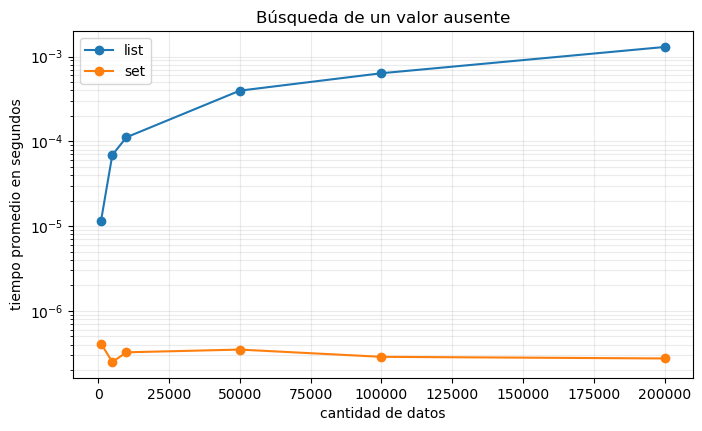

In [233]:
xs = [fila['tamano'] for fila in resultados]
ys_lista = [fila['tiempo_lista'] for fila in resultados]
ys_set = [fila['tiempo_conjunto'] for fila in resultados]

plt.figure(figsize=(8, 4.5))
plt.plot(xs, ys_lista, marker='o', label='list')
plt.plot(xs, ys_set, marker='o', label='set')
plt.yscale('log')
plt.xlabel('cantidad de datos')
plt.ylabel('tiempo promedio en segundos')
plt.title('Búsqueda de un valor ausente')
plt.grid(True, which='both', alpha=0.25)
plt.legend()
plt.show()

### Interpretación

Responde:

1. ¿Cuál fue más rápido?

El conjunto

2. ¿La diferencia crece con el tamaño?

En el conjunto, se podría afirmar que la diferencia no crece con el tamaño, que es constante, pues se tarda aproximadamente (más menos) lo mismo al verificar en una lista de 1000 elementos que en una de 200,000 (La diferencia varía debido al margen de error computacional). En cambio, en las listas la diferencia si crece directamente proporcional al tamaño.

3. ¿Qué estructura usarías si necesitas muchas búsquedas?

El conjunto definitavemente, pues en cuestión de tiempo el conjunto es mucho más eficiente que las listas, y en cuestión de recursos, es cierto que el crear un conjunto a partir de una lista tiene un costo, pero al hacer muchas búsquedas solamente hay im costo extra que da eficiencia en tiempo y recursos en cada búsqueda.

4. ¿Contamos aquí el costo de construir el conjunto? ¿Por qué importa esa pregunta?

No, no se cuenta pues primero se construyen los conjuntos y después se mide el tiempo. Sí importa esta pregunta, pues el contruir el conjunto también tiene costo.


## 7. Conteo con diccionario

Para contar frecuencias, una representación natural es:

$$\text{valor} \mapsto \text{frecuencia}$$

In [217]:
conteos_dict = contar_con_diccionario(datos)

print(f'Valores distintos: {len(conteos_dict):,}')
print('Primeros 8 pares valor -> frecuencia:')
for valor, frecuencia in list(conteos_dict.items())[:8]:
    print(f'{valor:>5} -> {frecuencia}')

Valores distintos: 10,000
Primeros 8 pares valor -> frecuencia:
 1824 -> 8
  409 -> 8
 4506 -> 14
 4012 -> 9
 3657 -> 15
 2286 -> 15
 1679 -> 8
 8935 -> 4


## 8. Conteo con `Counter`

`Counter` es una herramienta especializada de Python para contar ocurrencias.

In [218]:
conteos_counter = contar_con_counter(datos)

print('Los 8 valores más frecuentes:')
for valor, frecuencia in conteos_counter.most_common(8):
    print(f'{valor:>5} -> {frecuencia}')

assert dict(conteos_counter) == conteos_dict
print('El diccionario y Counter representan las mismas frecuencias.')

Los 8 valores más frecuentes:
 7289 -> 24
 7779 -> 23
 4009 -> 22
 9697 -> 21
 2001 -> 21
  897 -> 21
 9376 -> 21
 5269 -> 21
El diccionario y Counter representan las mismas frecuencias.


## 9. Comparar tiempos de conteo

La diferencia no siempre será enorme. Aquí también nos interesa la claridad de la representación.

In [219]:
tiempo_dict = medir_tiempo(lambda: contar_con_diccionario(datos), repeticiones=5)
tiempo_counter = medir_tiempo(lambda: contar_con_counter(datos), repeticiones=5)

print(f'Diccionario manual: {tiempo_dict:.8f} segundos')
print(f'Counter:            {tiempo_counter:.8f} segundos')

Diccionario manual: 0.00847926 segundos
Counter:            0.00388686 segundos


### Preguntas

1. ¿Qué hace más explícito el diccionario manual?

El diccionario hace explícito cuál es el tamaño de los elementos diferentes que conforman la lista, pues es un iterable y tiene longitud, en cambio el Counter al ser un objeto, no es iterable. También, el diccionario manual puede explícitamente buscar un valor, pues es iterable, en cambio para acceder a los datos de counter es necesario conocer sus métodos y saber cómo utilizarlos.

2. ¿Qué hace más cómodo `Counter`?

Que no hay que codificar nada, pues ya está hecho, solo debemos usar su estructura y acceder a sus métodos.

3. ¿Qué estructura usarías si necesitas contar frecuencias en un texto o una simulación?

Personalmente, usaría Counter, pues es más sencillo ya que ya está hecho y también porque se puede ver cómo es más rápido que la forma manual.

## 10. Complejidad intuitiva

Big-O describe cómo crece el costo cuando crece el tamaño de los datos. No es una medición exacta en segundos.

| Notación | Intuición | Ejemplo |
| --- | --- | --- |
| `O(1)` | aproximadamente constante | acceder a `datos[0]` |
| `O(n)` | proporcional al tamaño | recorrer una lista |
| `O(n²)` | doble recorrido | comparar todos contra todos |

In [220]:
#Este es el ejemplo O(1) ya que sin importar el tamaño de la lista, 
# el siempre tomar el primer elemento requiere una sola operación.
def ejemplo_constante(datos):
    return datos[0]

#Es es el ejemplo O(n) ya que el algoritmo debe verificar elemento a elemento 
# si el dato que queremos está en la lista, por lo que si hay n elementos, hay 
# que hacer n operaciones, una verificación por cada elemento.
def ejemplo_lineal(datos, objetivo):
    for dato in datos:
        if dato == objetivo:
            return True
    return False

#Este es el ejemplo O(n^2) pues compara cada elemento de la lista con todos los demás
# de esta forma, si la lista tiene n elementos, por cada elemento habrá n operaciones, 
# pues habrá n comparaciones. Así, se tiene un total de n^2 operaciones.
def ejemplo_cuadratico(datos):
    total = 0
    for a in datos:
        for b in datos:
            total += a == b
    return total


muestra = generar_datos(200)
print(ejemplo_constante(muestra))
print(ejemplo_lineal(muestra, -1))
print(ejemplo_cuadratico(muestra[:60]))

3
False
226


In [221]:

#Este es el ejemplo O(1) ya que sin importar el tamaño de la lista, 
# el siempre tomar el primer elemento requiere una sola operación.
def ejemplo_constante_g(datos):
    conteo_cte = 0
    d = datos[0]
    conteo_cte += 1
    return d, conteo_cte 

#Es es el ejemplo O(n) ya que el algoritmo debe verificar elemento a elemento 
# si el dato que queremos está en la lista, por lo que si hay n elementos, hay 
# que hacer n operaciones, una verificación por cada elemento.
def ejemplo_lineal_g(datos, objetivo):
    conteo_l = 0
    for dato in datos:
        conteo_l += 1
        if dato == objetivo:
            return True, conteo_l
    return False, conteo_l

#Este es el ejemplo O(n^2) pues compara cada elemento de la lista con todos los demás
# de esta forma, si la lista tiene n elementos, por cada elemento habrá n operaciones, 
# pues habrá n comparaciones. Así, se tiene un total de n^2 operaciones.
def ejemplo_cuadratico_g(datos):
    total = 0
    conteo_sqr = 0
    for a in datos:
        conteo_sqr += 1
        for b in datos:
            total += a == b
            conteo_sqr += 1
    return total, conteo_sqr

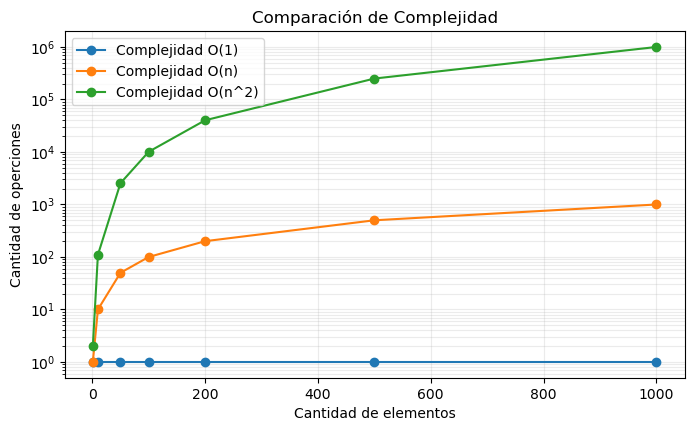

In [232]:
#Gráfica de las diferentes complejidades de los ejemplos de este ejercicio. Similar a la gráfica del ejercicio 6:


ext = [1, 10, 50, 100, 200, 500, 1000]

o1 = [ejemplo_constante_g(generar_datos(i))[1] for i in ext]
on = [ejemplo_lineal_g(generar_datos(i), -1)[1] for i in ext]
on2 = [ejemplo_cuadratico_g(generar_datos(i))[1] for i in ext]

plt.figure(figsize=(8, 4.5))
plt.plot(ext, o1, marker='o', label='Complejidad O(1)')
plt.plot(ext, on, marker='o', label='Complejidad O(n)')
plt.plot(ext, on2, marker='o', label='Complejidad O(n^2)')

plt.yscale('log')
plt.xlabel('Cantidad de elementos')
plt.ylabel('Cantidad de operciones')
plt.title('Comparación de Complejidad')
plt.grid(True, which='both', alpha=0.25)
plt.legend()
plt.show()

### Ejercicio

Clasifica los tres ejemplos anteriores como `O(1)`, `O(n)` u `O(n²)` y escribe una justificación breve para cada uno.

## 11. Ejercicio para completar

Cambia los tamaños y repeticiones. Observa si tu conclusión se mantiene.

In [223]:
# Puedes modificar estos valores.
tamanos_ejercicio = [7_000, 200_000, 8000_000]
repeticiones_ejercicio = 10

resultados_ejercicio = comparar_busquedas_por_tamano(
    tamanos_ejercicio,
    repeticiones=repeticiones_ejercicio,
)

for fila in resultados_ejercicio:
    print(fila)

{'tamano': 7000, 'tiempo_lista': 9.69899994743173e-05, 'tiempo_conjunto': 7.799993909429759e-07}
{'tamano': 200000, 'tiempo_lista': 0.0014740799997525755, 'tiempo_conjunto': 3.2000043574953453e-07}
{'tamano': 8000000, 'tiempo_lista': 0.04948041999959969, 'tiempo_conjunto': 3.6999990697950126e-07}


Escribe aquí tu conclusión:

- Estructura que usaría para muchas búsquedas: Conjunto
- Razón: La complejidad en la búsqueda con conjuntos es constante, a diferencia de la de las listas que es lineal
- Sacrificio posible: Perder información acerca del orden y de la frecuencia de aparición de los diferentes elementos

## 12. Actividad de proyecto / GitHub

Elige o crea uno de estos issues:

- `[DOC] Escribir guía de estilo`
- `[DOC] Documentar flujo básico de GitHub`
- `[TEST] Crear primera prueba de ejemplo`
- `[PROY] Definir estructura inicial de src/`

Flujo esperado:

`Issue → Branch → Commit → Pull Request → Review → Merge`

No trabajes directamente sobre `main`.

## 13. Reflexión final

Responde:

1. ¿Cuál fue más rápido: `list` o `set` para pertenencia?

Set

2. ¿La diferencia crece con el tamaño?

En el conjunto no. Pero en las listas sí y crece directamente propocional al tamaño.

3. ¿Qué estructura usarías si necesitas muchas búsquedas?

Conjuntos

4. ¿Qué estructura usarías si necesitas contar frecuencias?

Lisas

5. ¿Qué sacrificios tiene usar un `set` en lugar de una `list`?

Pierdes información en el orden y en la frecuencia de repetición

6. ¿Qué aprendiste al medir en lugar de solo razonar?

Aprendí a notar cual es el comportamiento de la complejidad de cada estructura 


## 14. Reto opcional

La búsqueda en `set` es rápida, pero construir el `set` también cuesta. Mide el costo total de:

1. Construir el conjunto.
2. Hacer muchas búsquedas.

Pregunta: ¿a partir de cuántas búsquedas empieza a convenir construir el conjunto?

Yo considero que realmente empieza a convenir a partir de que hay más de una consulta. Pues si es solo una, es el mismo costo el convertir a conjunto y luego buscar en él, que solamente buscar en la lista; sin embargo si vamos a hacer más de una vez la consulta, entonces conviene convertir a conjunto una sola vez y después solamente consultar cada vez en el conjunto.

In [224]:
def tiempo_consultas_lista(datos, consultas):
    inicio = time.perf_counter()
    for consulta in consultas:
        consulta in datos
    return time.perf_counter() - inicio


def tiempo_construir_set_y_consultar(datos, consultas):
    inicio = time.perf_counter()
    conjunto = set(datos)
    for consulta in consultas:
        consulta in conjunto
    return time.perf_counter() - inicio


datos_reto = generar_datos(30_000)

for cantidad in [1, 10, 50, 100, 500, 1_000]:
    consultas = [-1 - i for i in range(cantidad)]
    t_lista = tiempo_consultas_lista(datos_reto, consultas)
    t_set_total = tiempo_construir_set_y_consultar(datos_reto, consultas)
    print(f'{cantidad:>5,} consultas | lista: {t_lista:.5f}s | set total: {t_set_total:.5f}s')

    1 consultas | lista: 0.00044s | set total: 0.00042s
   10 consultas | lista: 0.00256s | set total: 0.00042s
   50 consultas | lista: 0.01558s | set total: 0.00054s
  100 consultas | lista: 0.02847s | set total: 0.00052s
  500 consultas | lista: 0.09859s | set total: 0.00083s
1,000 consultas | lista: 0.19749s | set total: 0.00038s
